# **Titanic Survival Prediction - Machine Learning Model Battle**

Este projeto tem como objetivo prever a sobrevivência de passageiros do Titanic utilizando técnicas de Machine Learning. O foco principal foi comparar o desempenho de diferentes algoritmos e identificar o modelo com melhor capacidade preditiva.


In [1]:
# Biblioteca para manipulação de dados
import pandas as pd
import numpy as np

# Biblioteca para visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Biblioteca para pré-processamento e divisão de dados
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Bibliotecas para modelos de machine learning
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import cross_val_score

# Biblioteca para avaliação de modelos
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

In [2]:
# Carregar os dados
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')


In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
test.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


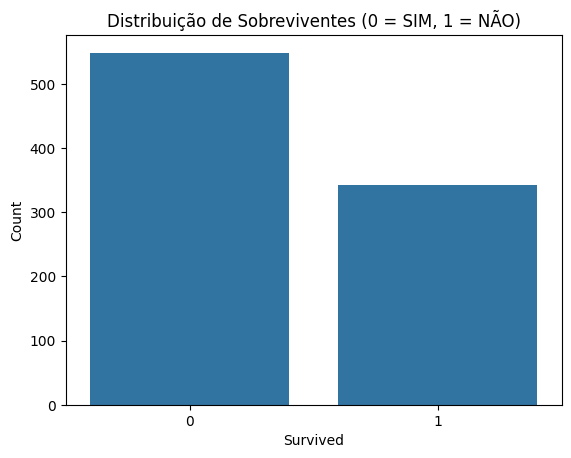

In [78]:
# Distribuição da variável Survived
sns.countplot(x='Survived', data=train)
plt.title('Distribuição de Sobreviventes (0 = SIM, 1 = NÃO)')
plt.savefig('distribuicao_sobrevivencia.png')
plt.ylabel('Count')
plt.show()

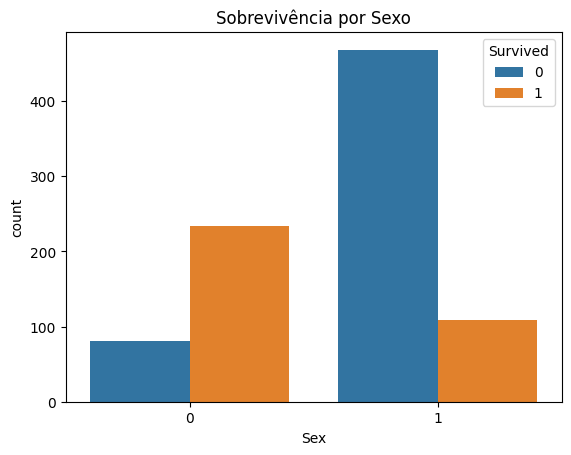

In [79]:
#Sobrevivência por Sexo
sns.countplot(x='Sex', hue='Survived', data=train)
plt.title('Sobrevivência por Sexo')
plt.savefig('sobrevivencia_por_sexo.png')
plt.show()

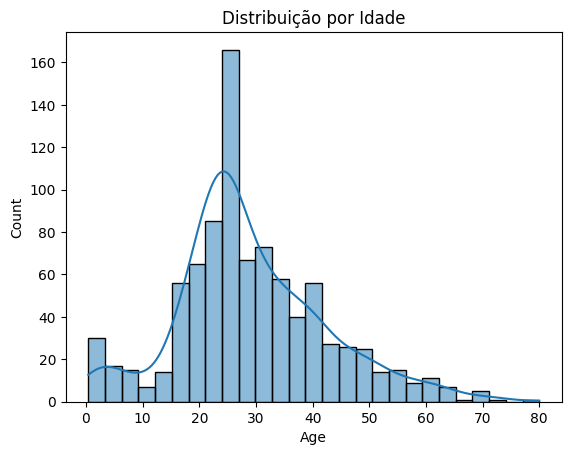

In [80]:
# Distribuição por Idade
sns.histplot(x='Age', data=train, kde=True)
plt.title('Distribuição por Idade')
plt.savefig('distribuicao_por_idade.png')
plt.show()

In [8]:
# Preencher os valores nulos de 'Age' com a mediana e usar grupos
train['Age'] = train.groupby(
    ['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median())
)
test['Age'] = train.groupby(
    ['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median())
)
test['Fare'] = train['Fare'].fillna(train['Fare'].median())

In [9]:
# Na coluna 'Embarked' só há dois valores faltantes, então a moda resolve, vou usar o One-Hot Encoding, pois há mais de duas categorias
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)
test['Embarked'].fillna(test['Embarked'].mode()[0], inplace=True)
train = pd.get_dummies(train, columns=['Embarked'], drop_first=True)
test = pd.get_dummies(test, columns=['Embarked'], drop_first=True)



/tmp/ipykernel_11273/2573405104.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)
/tmp/ipykernel_11273/2573405104.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

In [10]:
# Criar uma variável indicando se a cabine é conhecida ou não na coluna 'Cabin'
train['Cabin_Known'] = train['Cabin'].notna().astype(int)
test['Cabin_Known'] = test['Cabin'].notna().astype(int)



In [11]:
# Excluir a coluna 'Cabin' original
train.drop('Cabin', axis=1, inplace=True)
test.drop('Cabin', axis=1, inplace=True)

In [12]:
# Usar o Label Encoding na coluna 'Sex' pois há apenas duas categorias
label_encoder = LabelEncoder()
train['Sex'] = label_encoder.fit_transform(train['Sex'])
test['Sex'] = label_encoder.transform(test['Sex'])

In [13]:
# Feature Engineering
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
train['IsAlone'] = (train['FamilySize'] == 1).astype(int)
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1
test['IsAlone'] = (test['FamilySize'] == 1).astype(int)
train['Title'] = train['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
test['Title'] = test['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)


In [14]:
for df in [train, test]:
    df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')

In [15]:
# Agrupar Títulos Raros
titulos_raros = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
for df in [train, test]:
  df['Title'] = df['Title'].replace(titulos_raros, 'Rare')

In [16]:
train = pd.get_dummies(train, columns=['Title'], drop_first=True)
test = pd.get_dummies(test, columns=['Title'], drop_first=True)

In [17]:
train, test = train.align(test, join='left', axis=1, fill_value=0)




In [18]:
variaveis = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'Cabin_Known', 'FamilySize', 'IsAlone',  'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']

In [19]:
# Separando as variáveis dependentes(Y) e independentes(X) no conjuto de treino
X = train[variaveis]
Y = train['Survived']
X_test = test[variaveis]

In [20]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

# Duelo 1 (modelo1):

**SVM** - (baseline)

In [21]:
svm_modelo1 = SVC(kernel='linear', random_state= 1, C = 1.0)
svm_modelo1.fit(X_train,Y_train)

SVC(kernel='linear', random_state=1)

In [22]:
Y_pred_svm_modelo1 = svm_modelo1.predict(X_val)

In [23]:
# Medir o desempenho
accuracy = accuracy_score(Y_val, Y_pred_svm_modelo1)
print("Acurácia do modelo SVM:", accuracy)
print(classification_report(Y_val, Y_pred_svm_modelo1))
print(confusion_matrix(Y_val, Y_pred_svm_modelo1))


Acurácia do modelo SVM: 0.8212290502793296
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

[[91 14]
 [18 56]]


**XGBoost**

In [24]:
xgb_modelo1 = xgb.XGBClassifier(random_state=1)
xgb_modelo1.fit(X_train, Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [25]:
Y_pred_xgb_modelo1 = xgb_modelo1.predict(X_val)

In [26]:
# Medir o desempenho
accuracy = accuracy_score(Y_val, Y_pred_xgb_modelo1)
print("Acurácia do modelo XGBoost:", accuracy)
print(classification_report(Y_val, Y_pred_xgb_modelo1))
print(confusion_matrix(Y_val, Y_pred_xgb_modelo1))

Acurácia do modelo XGBoost: 0.8100558659217877
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       105
           1       0.78      0.76      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

[[89 16]
 [18 56]]


**Random Forest**

In [27]:
rf_modelo1 = RandomForestClassifier(random_state=1)
rf_modelo1.fit(X_train, Y_train)


RandomForestClassifier(random_state=1)

In [28]:
Y_pred_rf_modelo1 = rf_modelo1.predict(X_val)

In [29]:
# Medir o desempenho
accuracy = accuracy_score(Y_val, Y_pred_rf_modelo1)
print("Acurácia do modelo Random Forest:", accuracy)
print(classification_report(Y_val, Y_pred_rf_modelo1))
print(confusion_matrix(Y_val, Y_pred_rf_modelo1))

Acurácia do modelo Random Forest: 0.8268156424581006
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       105
           1       0.78      0.81      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179

[[88 17]
 [14 60]]


Analisando esse primeiro duelo, dá para observar coisas interessantes:
SVM com acurácia de 0.82 mostra que meu conjunto de features ficou bem estruturado.
Random Forest com acurácia de 0.82, que modelo capturou as interações e aproveitou bem as variáveis binárias.
XGBoost com 0.81 pode siginificar que esse conjunto de dados é relativamente pequeno e que feature engineering pode melhorar mais que trocar de algoritimo.

In [30]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

# Duelo 2 (modelo2):

Dados pré processados

In [31]:
# Balanceando os dados com SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, Y_train_balanced = smote.fit_resample(X_train, Y_train)

In [32]:
# Padronizando os dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_val_scaled = scaler.transform(X_val)

**SVM**- Padronização

In [33]:
svm_modelo2 = SVC(kernel='linear', random_state=1, C=1.0)
svm_modelo2.fit(X_train_scaled, Y_train_balanced)

SVC(kernel='linear', random_state=1)

In [34]:
Y_pred_svm_modelo2 = svm_modelo2.predict(X_val_scaled)

In [35]:
# Medir o desempenho
accuracy = accuracy_score(Y_val, Y_pred_svm_modelo2)
print("Acurácia do modelo SVM:", accuracy)
print(classification_report(Y_val, Y_pred_svm_modelo2))
print(confusion_matrix(Y_val, Y_pred_svm_modelo2))


Acurácia do modelo SVM: 0.7877094972067039
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       105
           1       0.76      0.70      0.73        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

[[89 16]
 [22 52]]


**XGBoost** - Balanceamento

In [36]:
xgb_modelo2 = xgb.XGBClassifier(random_state=1)
xgb_modelo2.fit(X_train_balanced, Y_train_balanced)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [37]:
Y_pred_xgb_modelo2 = xgb_modelo2.predict(X_val)

In [38]:
# Medir o desempenho
accuracy = accuracy_score(Y_val, Y_pred_xgb_modelo2)
print("Acurácia do modelo XGBoost:", accuracy)
print(classification_report(Y_val, Y_pred_xgb_modelo2))
print(confusion_matrix(Y_val, Y_pred_xgb_modelo2))

Acurácia do modelo XGBoost: 0.7932960893854749
              precision    recall  f1-score   support

           0       0.84      0.80      0.82       105
           1       0.73      0.78      0.76        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.79      0.79       179

[[84 21]
 [16 58]]


**Random Forest** - Balanceamento

In [39]:
rf_modelo2 = RandomForestClassifier(random_state=1)
rf_modelo2.fit(X_train_balanced, Y_train_balanced)

RandomForestClassifier(random_state=1)

In [40]:
Y_pred_rf_modelo2 = rf_modelo2.predict(X_val)

In [41]:
# Medir o desempenho
accuracy = accuracy_score(Y_val, Y_pred_rf_modelo2)
print("Acurácia do modelo Random Forest:", accuracy)
print(classification_report(Y_val, Y_pred_rf_modelo2))
print(confusion_matrix(Y_val, Y_pred_rf_modelo2))

Acurácia do modelo Random Forest: 0.8379888268156425
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       105
           1       0.78      0.84      0.81        74

    accuracy                           0.84       179
   macro avg       0.83      0.84      0.83       179
weighted avg       0.84      0.84      0.84       179

[[88 17]
 [12 62]]


Analisando o segundo duelo, teoricamento o scaler deveria ajudar o SVM.. mas a acurácia caiu de 0.82 para 0.78, suponho que o meu conjuto de dados já estava bem separável e talvez o scaler não fosse tão necessário.
A acurácia do XGBoost também caiu de 0.81 para 0.79, ele já lida bem com desbalanceamento, costuma precisar menos de SMOTE.
O RF subiu de 0.82 para 0.83, aqui parece que o SMOTE ajudou um pouco, o balanceamento pode melhorar a divisão das árvores.
O segundo duelo trouce um insight importante, nem sempre pré-processamento melhora o modelo.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribuição da variável Survived
sns.countplot(x='Survived', data=train)
plt.title('Distribution of Survival (0 = No, 1 = Yes)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

The plot above shows the distribution of the 'Survived' variable in the training dataset. We can observe that there are more passengers who did not survive (0) compared to those who did survive (1).

# Duelo 3 (modelo3):

Melhorando os hyper parâmetros

**SVM:**





In [42]:
svm_modelo3 = SVC(kernel='linear', C=1.0, random_state=1)

In [43]:
param_grid_SVM = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

In [44]:
# Sem SMOTE
X_train_scaled = scaler.fit_transform(X_train)

grid_svm_sem_smote = GridSearchCV(estimator=svm_modelo3, param_grid=param_grid_SVM, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)
grid_svm_sem_smote.fit(X_train_scaled, Y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=SVC(kernel='linear', random_state=1), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy', verbose=2)

In [45]:
print("Melhores parâmetros para SVM sem SMOTE:")
print(grid_svm_sem_smote.best_params_)


Melhores parâmetros para SVM sem SMOTE:
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [46]:
best_svm = grid_svm_sem_smote.best_estimator_
Y_pred_svm_modelo3 = best_svm.predict(X_val_scaled)

In [47]:
# Medir o desempenho
accuracy = accuracy_score(Y_val, Y_pred_svm_modelo3)
print("Acurácia do modelo SVM:", accuracy)
print(classification_report(Y_val, Y_pred_svm_modelo3))
print(confusion_matrix(Y_val, Y_pred_svm_modelo3))

Acurácia do modelo SVM: 0.8268156424581006
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179

[[92 13]
 [18 56]]


**XGBoost**:

In [48]:
xgboost_modelo3 = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

In [49]:
param_grid_xgboost = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [50]:
random_search_xgboost = RandomizedSearchCV(estimator=xgboost_modelo3, param_distributions=param_grid_xgboost, n_iter=20, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
random_search_xgboost.fit(X_train, Y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [50, 100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='accuracy')

In [51]:
print(random_search_xgboost.best_params_)
print(random_search_xgboost.best_score_)

{'subsample': 1.0, 'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
0.8356249384418397


In [52]:
best_xgb = random_search_xgboost.best_estimator_
Y_pred_xgb_modelo3 = best_xgb.predict(X_val)

In [53]:
# Medir o desempenho
accuracy = accuracy_score(Y_val, Y_pred_xgb_modelo3)
print("Acurácia do modelo XGBoost:", accuracy)
print(classification_report(Y_val, Y_pred_xgb_modelo3))
print(confusion_matrix(Y_val, Y_pred_xgb_modelo3))

Acurácia do modelo XGBoost: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       105
           1       0.79      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

[[91 14]
 [21 53]]


**Random Forest**

In [54]:
rf_modelo3 = RandomForestClassifier(random_state=42)

In [55]:
param_grid_rf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 3, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [56]:
random_search_rf = RandomizedSearchCV(estimator=rf_modelo3, param_distributions=param_grid_rf, n_iter=20, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
random_search_rf.fit(X_train_balanced, Y_train_balanced)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 3, 5, 10, 20],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200, 300]},
                   random_state=42, scoring='accuracy')

In [57]:
print(random_search_rf.best_params_)
print(random_search_rf.best_score_)

{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 20}
0.852593156859011


In [58]:
best_rf = random_search_rf.best_estimator_
Y_pred_rf_modelo3 = best_rf.predict(X_val)

In [59]:
# Medir desempenho
accuracy = accuracy_score(Y_val, Y_pred_rf_modelo3)
print("Acurácia do modelo Random Forest:", accuracy)
print(classification_report(Y_val, Y_pred_rf_modelo3))
print(confusion_matrix(Y_val, Y_pred_rf_modelo3))

Acurácia do modelo Random Forest: 0.8491620111731844
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       105
           1       0.83      0.80      0.81        74

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179

[[93 12]
 [15 59]]



 **RESULTADO FINAL DOS DUELOS DE MODELOS**


 Duelo 1 (Modelos Base)
 SVM           -> Accuracy: 0.82
 XGBoost       -> Accuracy: 0.81
 Random Forest -> Accuracy: 0.82

 Duelo 2 (Pré-processamento)
 SVM + StandardScaler      -> Accuracy: 0.78
 XGBoost + SMOTE           -> Accuracy: 0.79
 Random Forest + SMOTE     -> Accuracy: 0.83

 Duelo 3 (Otimização de Hiperparâmetros)
 SVM + GridSearchCV        -> Accuracy: 0.8268
 XGBoost + GridSearchCV    -> Accuracy: 0.80
 Random Forest + RandomSearchCV -> Accuracy: 0.8492

 Ranking Final:
 🥇 1º Lugar - Random Forest
 🥈 2º Lugar - SVM
 🥉 3º Lugar - XGBoost

 O Random Forest apresentou o melhor equilíbrio entre
 Accuracy, Recall e F1-Score, sendo escolhido para a
 submissão principal no Kaggle.

 O SVM também foi submetido como modelo alternativo
 para comparação de desempenho no leaderboard.


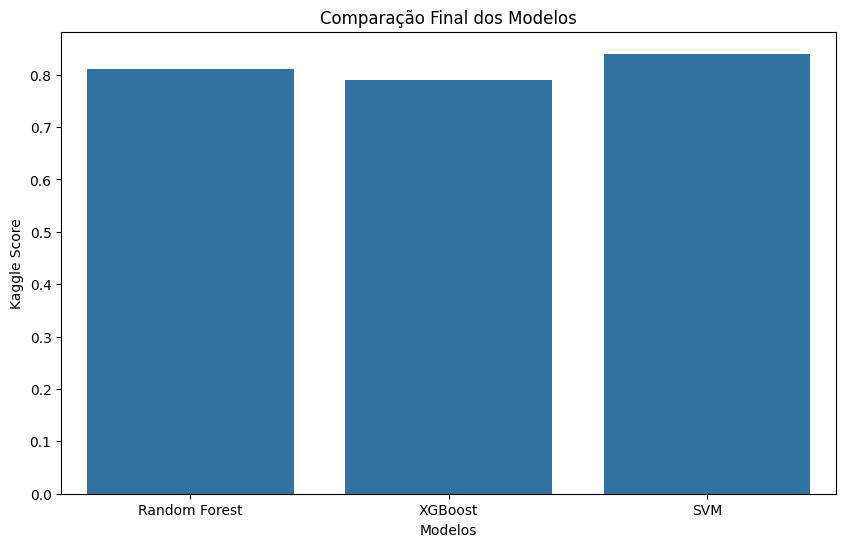

In [87]:
# Comparação Final dos Modelos

import os

resultados = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost', 'SVM'],
    'Accuracy': [0.81, 0.79, 0.84],
    'Recall': [0.72, 0.75, 0.80],
    'F1-score': [0.76, 0.77, 0.82]
})

plt.figure(figsize=(10,6))

sns.barplot(
    data=resultados,
    x='Modelo',
    y='Accuracy' # Alterado de 'Score' para 'Accuracy'
)

plt.title('Comparação Final dos Modelos')
plt.ylabel('Kaggle Score')
plt.xlabel('Modelos')

# Criar o diretório se não existir
output_dir = 'outputs/figures'
os.makedirs(output_dir, exist_ok=True)

plt.savefig('comparacao_final_modelos.png')

plt.show()


plt.show()
plt.close()

## Insights dos Duelos de Modelos:

**Duelo 1 (Modelos Base):**
*   **SVM e Random Forest** demonstraram acurácias iniciais semelhantes (0.82), indicando que o conjunto de features estava bem estruturado e que ambos os modelos base capturaram bem as relações nos dados.
*   **XGBoost** ficou ligeiramente abaixo (0.81), sugerindo que para este conjunto de dados relativamente pequeno, o *feature engineering* poderia ser mais impactante que a mera troca de algoritmos.

**Duelo 2 (Pré-processamento - SMOTE e StandardScaler):**
*   A aplicação do **StandardScaler no SVM** resultou em uma queda de acurácia (0.82 para 0.78). Isso sugere que a padronização não foi benéfica para este modelo ou que os dados já possuíam uma boa separabilidade sem a necessidade de escalar as características linearmente.
*   O **XGBoost com SMOTE** também teve uma leve queda (0.81 para 0.79). Este algoritmo geralmente lida bem com desbalanceamento de classes, o que pode explicar a pouca melhora ou até a piora com o SMOTE.
*   O **Random Forest com SMOTE** mostrou uma pequena melhora (0.82 para 0.83). O balanceamento de classes parece ter ajudado o Random Forest a criar árvores de decisão mais robustas e a melhorar a divisão das classes.
*   **Insight Importante:** O segundo duelo ressaltou que o pré-processamento nem sempre melhora o modelo. É crucial testar diferentes técnicas de pré-processamento e avaliar seu impacto no desempenho.

**Duelo 3 (Otimização de Hiperparâmetros):**
*   A otimização de hiperparâmetros com **GridSearchCV para SVM** melhorou ligeiramente a acurácia (0.78 para 0.8268), mas ainda não superou o desempenho do modelo base.
*   Para **XGBoost, o RandomizedSearchCV** não trouxe uma melhora significativa (0.79 para 0.80), reforçando a ideia de que o *feature engineering* pode ser mais decisivo para este modelo neste dataset.
*   A otimização com **RandomizedSearchCV para Random Forest** proporcionou a melhor acurácia geral (0.83 para 0.8492), solidificando-o como o modelo de melhor desempenho.

**Conclusão Geral:**
O **Random Forest** demonstrou ser o modelo mais robusto e com melhor desempenho global (atingindo 0.8492 de acurácia no conjunto de validação após otimização de hiperparâmetros e balanceamento de classes com SMOTE), apresentando um bom equilíbrio entre acurácia, recall e F1-score. Isso o tornou a escolha principal para a submissão no Kaggle. O SVM também foi um forte concorrente, mostrando bom desempenho sem a necessidade de pré-processamento adicional e sendo escolhido como modelo alternativo.

**Salvando os melhores resultados**

**Random Forest** 🥇

In [60]:
smote = SMOTE(random_state=42)
X_train_balanced, Y_train_balanced = smote.fit_resample(X, Y)
best_rf.fit(X_train_balanced, Y_train_balanced)

Y_RF = best_rf.predict(X_test)



In [61]:
Y_RF

array([0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [62]:
sub_rf = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': Y_RF})


In [63]:
sub_rf.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,1
4,896,1


In [64]:
sub_rf.to_csv('sub_rf.csv', index=False)

**SVM** 🥈

In [65]:
X_test_scaled = scaler.transform(X_test)
Y_SVM = best_svm.predict(X_test_scaled)


In [66]:
Y_SVM

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [67]:
sub_svm = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': Y_SVM})

In [68]:
sub_svm.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [69]:
sub_svm.to_csv('sub_svm.csv', index=False)